In [1]:
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch import amp
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import (confusion_matrix, classification_report,
                             f1_score, recall_score)

assert torch.cuda.is_available(), "CUDA 미탐지. 커널이 .venv인지 확인하세요."
device = torch.device("cuda")
torch.backends.cudnn.benchmark = True

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

print("torch :", torch.__version__)
print("GPU   :", torch.cuda.get_device_name(0))
print("VRAM  : %.1f GB" % (torch.cuda.get_device_properties(0).total_memory / 1024**3))

torch : 2.11.0+cu128
GPU   : NVIDIA GeForce RTX 5060 Laptop GPU
VRAM  : 8.0 GB


In [8]:
OUT = Path("outputs/garbage")
(OUT / "models").mkdir(parents=True, exist_ok=True)

IMG_SIZE     = 224
BATCH_SIZE   = 128      # OOM 나면 32로
EPOCHS       = 12
LR_HEAD      = 1e-3    # 새로 만든 분류기 — 랜덤 초기화라 크게
LR_BACKBONE  = 1e-4    # 사전학습층 — 이미 좋은 가중치라 조심스럽게
NUM_WORKERS  = 0       # 03에서 잘 돌아간 값으로 맞추세요
SEED         = 42

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

split     = pd.read_csv(OUT / "metrics" / "split.csv")
label_map = json.load(open(OUT / "metrics" / "label_map.json", encoding="utf-8"))
stats     = json.load(open(OUT / "metrics" / "norm_stats.json", encoding="utf-8"))
cw_df     = pd.read_csv(OUT / "metrics" / "class_weights.csv").sort_values("label_idx")

classes   = [c for c, _ in sorted(label_map.items(), key=lambda kv: kv[1])]
N_CLASSES = len(classes)

train_df = split[split.split == "train"].reset_index(drop=True)
val_df   = split[split.split == "val"].reset_index(drop=True)

mean, std = stats["imagenet_mean"], stats["imagenet_std"]   # ImageNet 통계
print(f"train {len(train_df):,} | val {len(val_df):,} | classes {N_CLASSES}")
print("정규화(ImageNet):", mean, std)

train 10,847 | val 2,324 | classes 12
정규화(ImageNet): [0.485, 0.456, 0.406] [0.229, 0.224, 0.225]


In [9]:
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.05, hue=0.0),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])


class GarbageDataset(Dataset):
    def __init__(self, df, transform):
        self.paths     = df["path"].tolist()
        self.targets   = df["label_idx"].tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")   # P모드 34장 대응
        return self.transform(img), self.targets[i]


train_ds = GarbageDataset(train_df, train_tf)
val_ds   = GarbageDataset(val_df,   eval_tf)

# 03의 결론에 따라 sampler 고정
per_class = cw_df.set_index("label_idx")["class_weight"].to_dict()
sample_w  = [per_class[t] for t in train_ds.targets]

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

x, y = train_ds[0]
print("샘플 텐서:", x.shape, "| 라벨:", y, classes[y])

샘플 텐서: torch.Size([3, 224, 224]) | 라벨: 0 battery


In [11]:
def build_model(mode):
    """mode: 'frozen' | 'finetune'"""
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, N_CLASSES)     # 1000 → 12

    if mode == "frozen":
        for name, p in m.named_parameters():
            p.requires_grad = name.startswith("fc.")

    return m.to(device)


def set_train_mode(model, mode):
    """frozen이면 backbone BN의 통계 갱신을 막는다"""
    model.train()
    if mode == "frozen":
        for mod in model.modules():
            if isinstance(mod, nn.BatchNorm2d):
                mod.eval()


for mode in ["frozen", "finetune"]:
    m = build_model(mode)
    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"{mode:9s} 전체 {total:,} | 학습 대상 {trainable:,} "
          f"({100 * trainable / total:.1f}%)")
    del m
torch.cuda.empty_cache()

frozen    전체 11,182,668 | 학습 대상 6,156 (0.1%)
finetune  전체 11,182,668 | 학습 대상 11,182,668 (100.0%)


In [12]:
def train_epoch(model, loader, criterion, optimizer, scaler, mode):
    set_train_mode(model, mode)
    loss_sum, correct, total = 0.0, 0, 0

    for inputs, labels in loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with amp.autocast("cuda", dtype=torch.float16):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        loss_sum += loss.item() * labels.size(0)
        correct  += outputs.argmax(1).eq(labels).sum().item()
        total    += labels.size(0)

    return loss_sum / total, 100 * correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    loss_sum, total = 0.0, 0
    preds, trues = [], []

    for inputs, labels in loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with amp.autocast("cuda", dtype=torch.float16):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        loss_sum += loss.item() * labels.size(0)
        total    += labels.size(0)
        preds.append(outputs.argmax(1).cpu())
        trues.append(labels.cpu())

    y_pred = torch.cat(preds).numpy()
    y_true = torch.cat(trues).numpy()

    return {"loss": loss_sum / total,
            "acc": 100 * (y_pred == y_true).mean(),
            "macro_f1": f1_score(y_true, y_pred, average="macro"),
            "y_pred": y_pred, "y_true": y_true}

In [13]:
def run_transfer(mode, epochs=EPOCHS):
    set_seed(SEED)
    model = build_model(mode)

    sampler = WeightedRandomSampler(sample_w, num_samples=len(sample_w),
                                    replacement=True)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                              num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
    criterion = nn.CrossEntropyLoss()

    if mode == "frozen":
        optimizer = optim.AdamW(model.fc.parameters(), lr=LR_HEAD, weight_decay=1e-4)
    else:
        backbone = [p for n, p in model.named_parameters() if not n.startswith("fc.")]
        optimizer = optim.AdamW(
            [{"params": backbone,               "lr": LR_BACKBONE},
             {"params": model.fc.parameters(),  "lr": LR_HEAD}],
            weight_decay=1e-4)

    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    scaler    = amp.GradScaler("cuda")

    ckpt = OUT / "models" / f"transfer_{mode}.pt"
    best_f1, history = -1.0, []
    t0 = time.time()

    print(f"\n{'=' * 70}\n[resnet18 / {mode}]  epochs={epochs}  "
          f"batches/epoch={len(train_loader)}\n{'=' * 70}")

    for ep in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion,
                                      optimizer, scaler, mode)
        va = evaluate(model, val_loader, criterion)
        scheduler.step()

        history.append({"epoch": ep, "train_loss": tr_loss, "train_acc": tr_acc,
                        "val_loss": va["loss"], "val_acc": va["acc"],
                        "val_macro_f1": va["macro_f1"]})

        star = ""
        if va["macro_f1"] > best_f1:
            best_f1 = va["macro_f1"]
            torch.save({"model": model.state_dict(), "mode": mode, "epoch": ep,
                        "val_macro_f1": best_f1, "classes": classes,
                        "img_size": IMG_SIZE}, ckpt)
            star = "  *best"

        print(f"  ep{ep:02d}  train {tr_loss:.3f}/{tr_acc:5.1f}%  "
              f"val {va['loss']:.3f}/{va['acc']:5.1f}%  macroF1 {va['macro_f1']:.4f}"
              f"  gap {tr_acc - va['acc']:+5.1f}p{star}")

    elapsed = time.time() - t0
    model.load_state_dict(torch.load(ckpt)["model"])
    final = evaluate(model, val_loader, criterion)
    recalls = recall_score(final["y_true"], final["y_pred"],
                           average=None, labels=range(N_CLASSES), zero_division=0)

    hist = pd.DataFrame(history)
    hist.to_csv(OUT / "metrics" / f"history_transfer_{mode}.csv",
                index=False, encoding="utf-8")

    print(f"  완료 {elapsed/60:.1f}분 | best macroF1 {best_f1:.4f} "
          f"(ep{int(hist['val_macro_f1'].idxmax()) + 1})")

    del model
    torch.cuda.empty_cache()

    return {"strategy": f"resnet18_{mode}", "history": hist, "final": final,
            "recalls": recalls, "minutes": elapsed / 60, "best_f1": best_f1}

In [7]:
_probe = run_transfer("frozen", epochs=1)
print(f"\nfrozen 1에폭 = {_probe['minutes']:.1f}분")
print("VRAM peak : %.2f GB" % (torch.cuda.max_memory_allocated() / 1024**3))
del _probe
torch.cuda.reset_peak_memory_stats()


[resnet18 / frozen]  epochs=1  batches/epoch=169
  ep01  train 0.995/ 73.3%  val 0.465/ 87.3%  macroF1 0.8222  gap -14.1p  *best
  완료 0.9분 | best macroF1 0.8222 (ep1)

frozen 1에폭 = 0.9분
VRAM peak : 0.72 GB


In [14]:
results = {}
for mode in ["frozen", "finetune"]:
    results[mode] = run_transfer(mode)


[resnet18 / frozen]  epochs=12  batches/epoch=84
  ep01  train 1.261/ 66.4%  val 0.559/ 85.9%  macroF1 0.8016  gap -19.5p  *best
  ep02  train 0.579/ 85.0%  val 0.415/ 88.3%  macroF1 0.8344  gap  -3.4p  *best
  ep03  train 0.451/ 87.4%  val 0.373/ 89.3%  macroF1 0.8485  gap  -1.9p  *best
  ep04  train 0.394/ 88.8%  val 0.362/ 89.9%  macroF1 0.8595  gap  -1.1p  *best
  ep05  train 0.358/ 89.5%  val 0.343/ 90.4%  macroF1 0.8675  gap  -0.9p  *best
  ep06  train 0.348/ 89.9%  val 0.324/ 90.9%  macroF1 0.8739  gap  -0.9p  *best
  ep07  train 0.320/ 90.8%  val 0.326/ 90.8%  macroF1 0.8735  gap  +0.1p
  ep08  train 0.315/ 90.6%  val 0.331/ 90.8%  macroF1 0.8738  gap  -0.2p
  ep09  train 0.296/ 91.2%  val 0.316/ 91.1%  macroF1 0.8773  gap  +0.1p  *best
  ep10  train 0.310/ 90.8%  val 0.318/ 91.1%  macroF1 0.8771  gap  -0.2p
  ep11  train 0.305/ 91.0%  val 0.315/ 91.6%  macroF1 0.8833  gap  -0.6p  *best
  ep12  train 0.311/ 91.1%  val 0.314/ 91.7%  macroF1 0.8841  gap  -0.5p  *best
  완료 9.9분 |

In [15]:
rows = []
for m, r in results.items():
    f = r["final"]
    rows.append({"model": f"resnet18_{m}",
                 "val_acc":    round(f["acc"], 2),
                 "macro_f1":   round(f["macro_f1"], 4),
                 "min_recall": round(float(r["recalls"].min()), 3),
                 "worst_class": classes[int(r["recalls"].argmin())],
                 "recall_std": round(float(r["recalls"].std()), 3),
                 "minutes":    round(r["minutes"], 1)})

transfer_summary = pd.DataFrame(rows)

# 03의 sampler 결과를 같은 표에 붙인다
base = pd.read_csv(OUT / "metrics" / "baseline_comparison.csv")
base_row = base[base["strategy"] == "sampler"].iloc[0]
scratch = pd.DataFrame([{
    "model": "GarbageCNN_scratch", "val_acc": base_row["val_acc"],
    "macro_f1": base_row["macro_f1"], "min_recall": base_row["min_recall"],
    "worst_class": base_row["worst_class"], "recall_std": base_row["recall_std"],
    "minutes": base_row["minutes"]}])

compare = pd.concat([scratch, transfer_summary], ignore_index=True)
compare.to_csv(OUT / "metrics" / "transfer_comparison.csv",
               index=False, encoding="utf-8")
print(compare.to_string(index=False))

             model  val_acc  macro_f1  min_recall worst_class  recall_std  minutes
GarbageCNN_scratch    61.14    0.5786       0.304       shoes       0.181      9.5
   resnet18_frozen    91.65    0.8841       0.608     plastic       0.106      9.9
 resnet18_finetune    95.14    0.9371       0.785     plastic       0.057     11.5


In [16]:
rec = pd.DataFrame({m: results[m]["recalls"] for m in results}, index=classes)
rec.insert(0, "val_n",
           val_df["label_idx"].value_counts().reindex(range(N_CLASSES)).values)
print("클래스별 recall (val)")
print(rec.round(3).to_string())

클래스별 recall (val)
             val_n  frozen  finetune
battery        142   0.958     0.986
biological     148   0.980     0.993
brown-glass     91   0.912     0.956
cardboard      133   0.857     0.940
clothes        798   0.955     0.965
green-glass     92   0.978     1.000
metal          116   0.940     0.905
paper          157   0.803     0.924
plastic        130   0.608     0.785
shoes          296   0.983     0.980
trash          105   0.962     0.981
white-glass    116   0.810     0.905


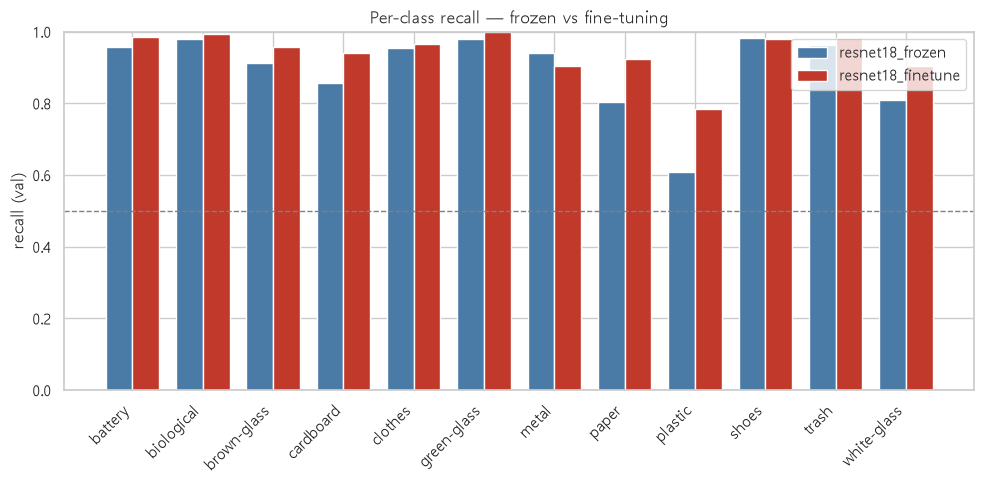

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
x, width = np.arange(N_CLASSES), 0.38
colors = {"frozen": "#4a7ba7", "finetune": "#c0392b"}

for i, m in enumerate(results):
    ax.bar(x + (i - 0.5) * width, results[m]["recalls"], width,
           label=f"resnet18_{m}", color=colors[m])

ax.set_xticks(x); ax.set_xticklabels(classes, rotation=45, ha="right")
ax.set_ylabel("recall (val)"); ax.set_ylim(0, 1)
ax.set_title("Per-class recall — frozen vs fine-tuning")
ax.axhline(0.5, ls="--", lw=1, color="gray")
ax.legend()
plt.tight_layout()
plt.savefig(OUT / "figures" / "11_transfer_recall.png", dpi=150)
plt.show()

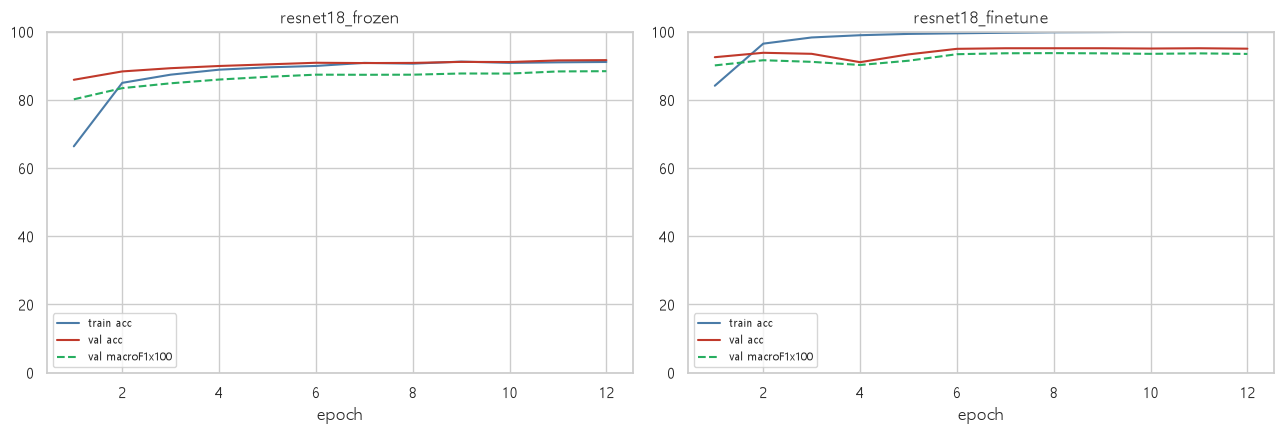

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, m in zip(axes, results):
    h = results[m]["history"]
    ax.plot(h["epoch"], h["train_acc"], label="train acc", color="#4a7ba7")
    ax.plot(h["epoch"], h["val_acc"],   label="val acc",   color="#c0392b")
    ax.plot(h["epoch"], h["val_macro_f1"] * 100, label="val macroF1x100",
            color="#27ae60", ls="--")
    ax.set_title(f"resnet18_{m}"); ax.set_xlabel("epoch"); ax.set_ylim(0, 100)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT / "figures" / "12_transfer_curves.png", dpi=150)
plt.show()

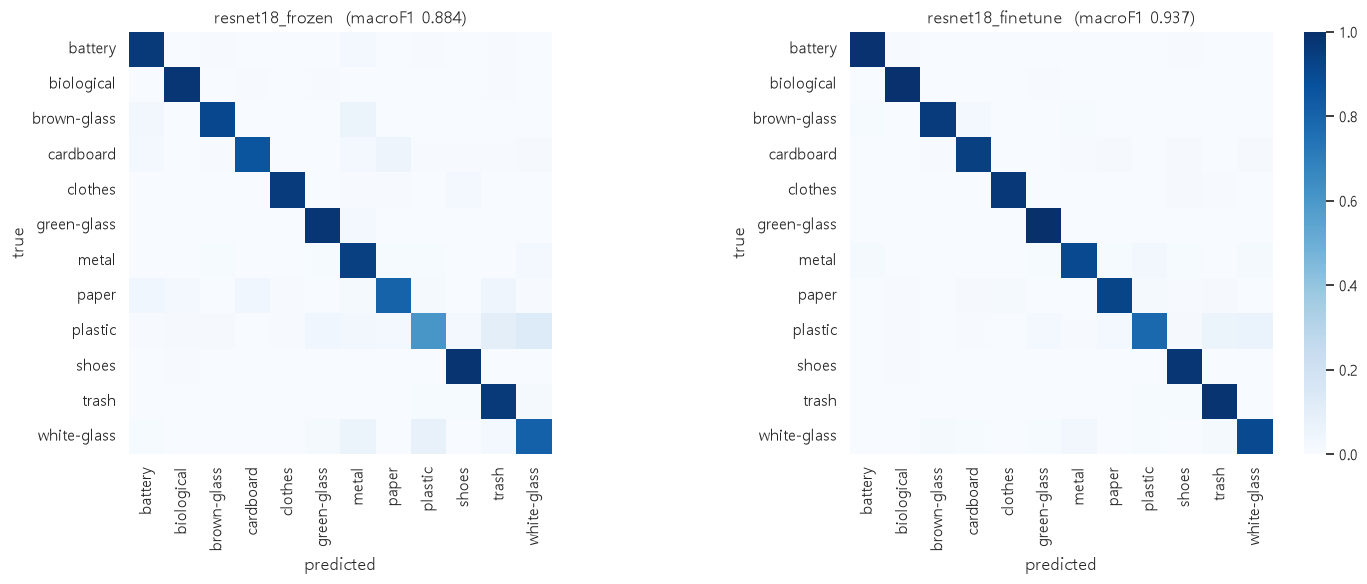

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, m in zip(axes, results):
    f = results[m]["final"]
    cm = confusion_matrix(f["y_true"], f["y_pred"], labels=range(N_CLASSES))
    cmn = cm / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cmn, ax=ax, cmap="Blues", vmin=0, vmax=1,
                cbar=(m == "finetune"), square=True,
                xticklabels=classes, yticklabels=classes)
    ax.set_title(f"resnet18_{m}  (macroF1 {f['macro_f1']:.3f})")
    ax.set_xlabel("predicted"); ax.set_ylabel("true")

plt.tight_layout()
plt.savefig(OUT / "figures" / "13_transfer_confusion.png", dpi=150)
plt.show()

In [20]:
best_name = compare.sort_values("macro_f1", ascending=False).iloc[0]["model"]
print("최종 선택:", best_name)
print()

if best_name.startswith("resnet18_"):
    r = results[best_name.replace("resnet18_", "")]["final"]
    print(classification_report(r["y_true"], r["y_pred"],
                                target_names=classes, digits=3, zero_division=0))
else:
    print("scratch 모델이 최고 — 05에서 baseline 체크포인트를 사용하세요.")

최종 선택: resnet18_finetune

              precision    recall  f1-score   support

     battery      0.979     0.986     0.982       142
  biological      0.961     0.993     0.977       148
 brown-glass      0.946     0.956     0.951        91
   cardboard      0.940     0.940     0.940       133
     clothes      0.995     0.965     0.980       798
 green-glass      0.929     1.000     0.963        92
       metal      0.929     0.905     0.917       116
       paper      0.942     0.924     0.932       157
     plastic      0.887     0.785     0.833       130
       shoes      0.935     0.980     0.957       296
       trash      0.858     0.981     0.916       105
 white-glass      0.890     0.905     0.897       116

    accuracy                          0.951      2324
   macro avg      0.933     0.943     0.937      2324
weighted avg      0.952     0.951     0.951      2324



In [21]:
# 실험 로그 누적
exp_path = OUT / "metrics" / "experiments.csv"
log = transfer_summary.assign(img_size=IMG_SIZE, epochs=EPOCHS, strategy="sampler")

if exp_path.exists():
    prev = pd.read_csv(exp_path)
    log = pd.concat([prev, log], ignore_index=True)

log.to_csv(exp_path, index=False, encoding="utf-8")
print(log.to_string(index=False))
print("\n체크포인트:", *[p.name for p in sorted((OUT / "models").glob("transfer_*.pt"))])

    strategy  val_acc  macro_f1  min_recall worst_class  recall_std  minutes               model  img_size  epochs
        none    64.33    0.5715       0.181       metal       0.217     10.0 GarbageCNN(scratch)       128      15
class_weight    59.90    0.5681       0.301       shoes       0.183     10.4 GarbageCNN(scratch)       128      15
     sampler    61.14    0.5786       0.304       shoes       0.181      9.5 GarbageCNN(scratch)       128      15
     sampler    91.65    0.8841       0.608     plastic       0.106      9.9     resnet18_frozen       224      12
     sampler    95.14    0.9371       0.785     plastic       0.057     11.5   resnet18_finetune       224      12

체크포인트: transfer_finetune.pt transfer_frozen.pt
